In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib
matplotlib.style.use('fivethirtyeight')

import random
random.seed(9001)

# Loading Dataset

In [45]:
main_df = pd.read_csv('insurance_claims.csv')
main_df.head(2)
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

# Handling Missing Values

In [46]:
main_df.isna().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [47]:
# missing value:
# authorities_contacted has 91 missing value (1000 - 909)
# fill NA for this features by setting NA = Other

main_df['authorities_contacted'] = main_df['authorities_contacted'].fillna('Other')

In [48]:
# drop _c39 column due to missing value
main_df.drop('_c39', axis = 1, inplace=True)

In [49]:
# print unique value for each columns

for col in main_df.columns:
    print(f"{col}: \n{main_df[col].unique()}\n")


months_as_customer: 
[328 228 134 256 137 165  27 212 235 447  60 121 180 473  70 140 160 196
 460 217 370 413 237   8 257 202 224 241  64 166 155 114 149 147  62 289
 431 199  79 116  37 106 269 265 163 355 175 192 430  91 223 195  22 439
  94  11 151 154 245 119 215 295 254 107 478 128 338 271 222 120 270 319
 194 227 244  78 200 284 275 153  31  41 127  61 207 219  80 325  29 239
 279 350 464 118 298  87 261 453 210 168 390 258 225 164 255 206 203 211
 274  81 280 112  24  93 171 124 287 122 398 214 209  82 193 288 104 101
 375 461 428  45 136 216 278 108  14 276  47  73 294 324  53 426 111  86
 296 125 177 238 449 252 359  19 285  30 342 468 343 404  63 335 142 272
  69  38 281 246 330 362 371 377 172  99 249 190 174  95   2 117 242 440
  20 208 156 232  84 394  35 369 332 243 264  32 259 186 201 436 189 105
  88  40  59  39 123 231 247  48 267 286 253  10 158   1  85 233 266  97
 399 305 129 283  96 176 159 290 299  66 334 429  15 230 250  65 475  77
 229 110 292 451 150 291 162 3

In [50]:
main_df.groupby(['collision_type']).agg({'policy_number':'count'}).reset_index()

,collision_type,policy_number
0,?,178
1,Front Collision,254
2,Rear Collision,292
3,Side Collision,276


In [51]:
main_df.groupby(['property_damage']).agg({'policy_number':'count'}).reset_index()

,property_damage,policy_number
0,?,360
1,NO,338
2,YES,302


In [52]:
main_df.groupby(['police_report_available']).agg({'policy_number':'count'}).reset_index()

,police_report_available,policy_number
0,?,343
1,NO,343
2,YES,314


In [ ]:
# replace '?' the the most frequent categorical variable at the same columns
main_df.replace({'collision_type': {'?': 'Rear Collision'}, 'property_damage': {'?': 'NO'}, 'police_report_available': {'?': 'NO'}}, inplace=True)

In [54]:
main_df.shape

(1000, 39)

In [55]:
# Change datatype
# policy_bind_date should be date type
# incident_date should be date type
main_df[["policy_bind_date", "incident_date"]] = main_df[["policy_bind_date", "incident_date"]].apply(pd.to_datetime)

main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   months_as_customer           1000 non-null   int64         
 1   age                          1000 non-null   int64         
 2   policy_number                1000 non-null   int64         
 3   policy_bind_date             1000 non-null   datetime64[ns]
 4   policy_state                 1000 non-null   object        
 5   policy_csl                   1000 non-null   object        
 6   policy_deductable            1000 non-null   int64         
 7   policy_annual_premium        1000 non-null   float64       
 8   umbrella_limit               1000 non-null   int64         
 9   insured_zip                  1000 non-null   int64         
 10  insured_sex                  1000 non-null   object        
 11  insured_education_level      1000 non-null  

# EDA

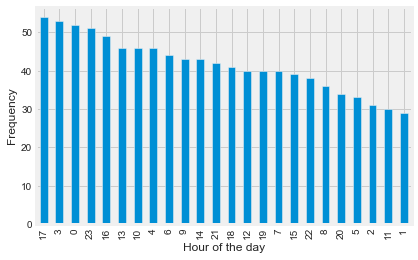

In [58]:
# Bar plot number of incidence per hour
fig, ax = plt.subplots()
#plt.figure(figsize = (18, 12))

main_df['incident_hour_of_the_day'].value_counts().plot(ax=ax, kind='bar', xlabel='Hour of the day', ylabel='Frequency')
plt.show()
# incidences mostly happens at 17.00

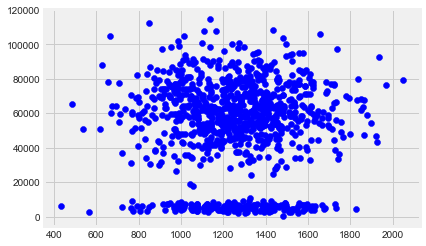

In [59]:
# scatter plot of annual premium vs total claim amount
plt.scatter(x = main_df['policy_annual_premium'], y = main_df['total_claim_amount'], c = 'blue')
plt.show()

Text(0.5, 0, 'Count')

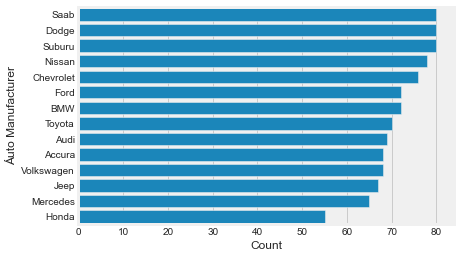

In [60]:
sns.countplot(y='auto_make',data=main_df, order = main_df['auto_make'].value_counts().index)
plt.ylabel('Áuto Manufacturer')
plt.xlabel('Count')

In [62]:
# by auto_make
fraud_by_automake = main_df.groupby(['auto_make', 'fraud_reported']).agg({'fraud_reported': 'count'})
fraud_by_automake.groupby(level=0).apply(lambda x: round(100 * x / float(x.sum())))
# Audi, Mercedes, ford : fraud >30%

fraud_reported
auto_make  auto_make  fraud_reported                
Accura     Accura     N                         81.0
                      Y                         19.0
Audi       Audi       N                         70.0
                      Y                         30.0
BMW        BMW        N                         72.0
                      Y                         28.0
Chevrolet  Chevrolet  N                         72.0
                      Y                         28.0
Dodge      Dodge      N                         75.0
                      Y                         25.0
Ford       Ford       N                         69.0
                      Y                         31.0
Honda      Honda      N                         75.0
                      Y                         25.0
Jeep       Jeep       N                         84.0
                      Y                         16.0
Mercedes   Mercedes   N                         66.0
                      Y                         34.0
Nissan     Nissan     N                         82.0
                      Y                         18.0
Saab       Saab       N                         78.0
                      Y                         22.0
Suburu     Suburu     N                         76.0
                      Y                         24.0
Toyota     Toyota     N                         81.0
                      Y                         19.0
Volkswagen Volkswagen N                         72.0
                      Y                         28.0

<Axes: xlabel='count', ylabel='auto_make'>

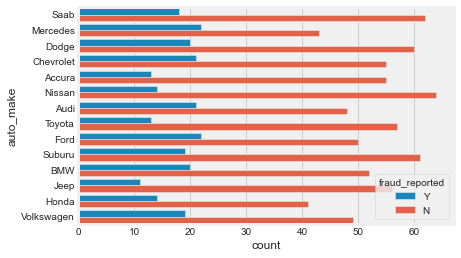

In [63]:
sns.countplot(y='auto_make',hue='fraud_reported',data=main_df)


In [57]:
# Heatmap correlation plot for all variables

plt.figure(figsize = (18, 12))

corr = main_df.corr()
#mask = np.triu(np.ones_like(corr, dtype = bool))
# mask = mask,
sns.heatmap(data = corr,  annot = True, fmt = '.1g', linewidth = 1)
plt.show()

ValueError: could not convert string to float: 'OH'

<Figure size 1296x864 with 0 Axes>